# A3 Tiny Transformer

```text
Raw Shakespeare text
  -> BPE subword tokenizer
  -> integer token ids
  -> input/target sequences
  -> Tiny causal Transformer
  -> train/validation loss
  -> validation perplexity
  -> attention heatmap
```

## 0. 作业检查清单

你最终报告里至少需要有：

- 数据和 tokenizer 设置：vocab size、context length、train/val split
- 模型结构：embedding、positional encoding、causal self-attention、RMSNorm、FFN、residual connection
- 训练设置：loss、optimizer、learning rate、batch size、epoch
- 训练曲线：train loss 和 validation loss
- validation perplexity：`PPL = exp(validation cross-entropy loss)`
- attention heatmap 和文字解释
- AI tool usage disclosure

In [15]:
# 1. Imports and configuration

import math
import random
import re
import time
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

DATA_PATH = Path("Shakespeare Tiny Corpus.txt")

CFG = {
    # Tokenizer
    "vocab_size": 500,          
    "tokenizer_train_chars": None,  

    # Data
    "block_size": 64,           
    "batch_size": 32,
    "train_split": 0.80,
    "stride": 1,                # 1 overlapping sequences

    # Model
    "d_model": 64,
    "n_heads": 4,
    "n_layers": 2,
    "dropout": 0.10,
    "ff_mult": 4,

    # Training
    "epochs": 5,
    "learning_rate": 3e-4,
    "weight_decay": 0.01,
    "grad_clip": 1.0,
    "max_train_batches_per_epoch": 150,  
    "max_val_batches": 50,
}

assert CFG["d_model"] % CFG["n_heads"] == 0

Using device: cuda


In [16]:
# 2. Load the Shakespeare corpus

text = DATA_PATH.read_text(encoding="utf-8")

print(f"Characters: {len(text):,}")
print("Preview:")
print(repr(text[:500]))

Characters: 1,115,394
Preview:
"First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to die than to famish?\n\nAll:\nResolved. resolved.\n\nFirst Citizen:\nFirst, you know Caius Marcius is chief enemy to the people.\n\nAll:\nWe know't, we know't.\n\nFirst Citizen:\nLet us kill him, and we'll have corn at our own price.\nIs't a verdict?\n\nAll:\nNo more talking on't; let it be done: away, away!\n\nSecond Citizen:\nOne word, good citizens.\n\nFirst Citizen:\nWe are accounted poor"


## 1. Subword Tokenizer: simple BPE

In [17]:
# 3. A small BPE

class SimpleBPETokenizer:
    def __init__(self, vocab_size=500):
        self.vocab_size = vocab_size
        self.merges = []
        self.token_to_id = {}
        self.id_to_token = []
        self.unk_token = "<unk>"
        self.unk_id = 0

    @staticmethod
    def _split_text(text):
        # Preserve spaces and newlines as tokens, because Shakespeare formatting matters.
        return re.findall(r"\s+|[^\s]+", text)

    @staticmethod
    def _merge_pair(symbols, pair):
        merged = []
        i = 0
        while i < len(symbols):
            if i < len(symbols) - 1 and (symbols[i], symbols[i + 1]) == pair:
                merged.append(symbols[i] + symbols[i + 1])
                i += 2
            else:
                merged.append(symbols[i])
                i += 1
        return tuple(merged)

    def fit(self, text):
        segments = self._split_text(text)
        word_freq = Counter(tuple(seg) for seg in segments if seg)

        base_symbols = sorted({ch for seg in segments for ch in seg})
        vocab = {self.unk_token, *base_symbols}

        if len(vocab) > self.vocab_size:
            raise ValueError(
                f"vocab_size={self.vocab_size} is too small for {len(vocab)} base symbols."
            )

        target_merges = self.vocab_size - len(vocab)
        print(f"Base symbols: {len(vocab)} including <unk>")
        print(f"Learning up to {target_merges} BPE merges...")

        for step in range(target_merges):
            pair_counts = Counter()
            for symbols, freq in word_freq.items():
                if len(symbols) < 2:
                    continue
                for pair in zip(symbols, symbols[1:]):
                    pair_counts[pair] += freq

            if not pair_counts:
                break

            best_pair, best_count = pair_counts.most_common(1)[0]
            self.merges.append(best_pair)
            vocab.add(best_pair[0] + best_pair[1])

            new_word_freq = Counter()
            for symbols, freq in word_freq.items():
                new_word_freq[self._merge_pair(symbols, best_pair)] += freq
            word_freq = new_word_freq

            if (step + 1) % 50 == 0:
                print(f"  merge {step + 1:3d}: {best_pair} count={best_count:,}")

        self.id_to_token = [self.unk_token] + sorted(vocab - {self.unk_token})
        self.token_to_id = {tok: i for i, tok in enumerate(self.id_to_token)}
        self.unk_id = self.token_to_id[self.unk_token]

        print(f"Final vocab size: {len(self.id_to_token)}")
        return self

    def _encode_segment(self, segment):
        symbols = tuple(segment)
        for pair in self.merges:
            symbols = self._merge_pair(symbols, pair)
        return [self.token_to_id.get(sym, self.unk_id) for sym in symbols]

    def encode(self, text):
        ids = []
        cache = {}
        for segment in self._split_text(text):
            if segment not in cache:
                cache[segment] = self._encode_segment(segment)
            ids.extend(cache[segment])
        return ids

    def decode(self, ids):
        pieces = []
        for idx in ids:
            tok = self.id_to_token[int(idx)]
            if tok != self.unk_token:
                pieces.append(tok)
        return "".join(pieces)

    def pretty_token(self, idx, max_len=12):
        tok = self.id_to_token[int(idx)]
        tok = tok.replace("\n", "\\n").replace("\t", "\\t").replace(" ", "·")
        if len(tok) > max_len:
            tok = tok[:max_len] + "..."
        return tok

In [18]:
# 4. Train tokenizer and encode the whole corpus

fit_text = text if CFG["tokenizer_train_chars"] is None else text[: CFG["tokenizer_train_chars"]]

tokenizer = SimpleBPETokenizer(vocab_size=CFG["vocab_size"])
tokenizer.fit(fit_text)

all_ids = tokenizer.encode(text)

print(f"Encoded tokens: {len(all_ids):,}")
print(f"Compression ratio: {len(text) / len(all_ids):.2f} characters/token")
print("Round-trip sanity check:")
print(repr(tokenizer.decode(all_ids[:80])))

assert len(tokenizer.id_to_token) <= CFG["vocab_size"]
assert len(all_ids) > CFG["block_size"] + 1

Base symbols: 66 including <unk>
Learning up to 434 BPE merges...
  merge  50: ('d', 'e') count=2,056
  merge 100: ('th', 'y') count=1,077
  merge 150: ('E', 'R') count=665
  merge 200: ('w', 'ould') count=496
  merge 250: ('in', 'k') count=382
  merge 300: ('w', 'hich') count=313
  merge 350: ('O', ',') count=268
  merge 400: ('m', 'is') count=229
Final vocab size: 500
Encoded tokens: 641,904
Compression ratio: 1.74 characters/token
Round-trip sanity check:
'First Citizen:\nBefore we proceed any further, hear me speak.\n\nAll:\nSpeak, speak.\n\nFirst Citizen:\nYou are all resolved rather to die than to fam'


## 2. Next-token prediction dataset

```text
x = [token_0, token_1, ..., token_62, token_63]
y = [token_1, token_2, ..., token_63, token_64]
```

In [19]:
# 5. Train/validation split and Dataset

split_idx = int(len(all_ids) * CFG["train_split"])
train_ids = all_ids[:split_idx]
val_ids = all_ids[split_idx:]

print(f"Train tokens: {len(train_ids):,}")
print(f"Val tokens:   {len(val_ids):,}")

class NextTokenDataset(Dataset):
    def __init__(self, token_ids, block_size, stride=1):
        self.tokens = torch.tensor(token_ids, dtype=torch.long)
        self.block_size = block_size
        self.stride = stride
        self.num_examples = (len(self.tokens) - block_size - 1) // stride

    def __len__(self):
        return self.num_examples

    def __getitem__(self, idx):
        start = idx * self.stride
        end = start + self.block_size
        x = self.tokens[start:end]
        y = self.tokens[start + 1 : end + 1]
        return x, y

train_ds = NextTokenDataset(train_ids, CFG["block_size"], stride=CFG["stride"])
val_ds = NextTokenDataset(val_ids, CFG["block_size"], stride=CFG["stride"])

train_loader = DataLoader(
    train_ds,
    batch_size=CFG["batch_size"],
    shuffle=True,
    drop_last=True,
    num_workers=0,
    pin_memory=(DEVICE == "cuda"),
)

val_loader = DataLoader(
    val_ds,
    batch_size=CFG["batch_size"],
    shuffle=False,
    drop_last=False,
    num_workers=0,
    pin_memory=(DEVICE == "cuda"),
)

xb, yb = next(iter(train_loader))
print("x shape:", xb.shape)
print("y shape:", yb.shape)
print("x sample decoded:")
print(repr(tokenizer.decode(xb[0].tolist())))
print("y sample decoded:")
print(repr(tokenizer.decode(yb[0].tolist())))

Train tokens: 513,523
Val tokens:   128,381
x shape: torch.Size([32, 64])
y shape: torch.Size([32, 64])
x sample decoded:
'p forth mine advocate; at your request\nMy father will grant precious things as trifles.\n\nLEONTES:\nWould he do so,'
y sample decoded:
' forth mine advocate; at your request\nMy father will grant precious things as trifles.\n\nLEONTES:\nWould he do so, '


## 3. Tiny Transformer model

```text
x -> RMSNorm -> causal multi-head self-attention -> residual add
  -> RMSNorm -> feed-forward network -> residual add
```

In [20]:
# 6. RMSNorm and sinusoidal positional encoding

class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-8):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        rms = torch.sqrt(torch.mean(x * x, dim=-1, keepdim=True) + self.eps)
        return self.weight * (x / rms)


class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, block_size, d_model):
        super().__init__()
        pe = torch.zeros(block_size, d_model)
        position = torch.arange(0, block_size, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2, dtype=torch.float) * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term[: pe[:, 1::2].shape[1]])
        self.register_buffer("pe", pe.unsqueeze(0))  # [1, block_size, d_model]

    def forward(self, x):
        T = x.size(1)
        return x + self.pe[:, :T, :]

In [21]:
# 7. Causal multi-head self-attention

class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, block_size, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads

        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.attn_dropout = nn.Dropout(dropout)
        self.resid_dropout = nn.Dropout(dropout)

        mask = torch.tril(torch.ones(block_size, block_size, dtype=torch.bool))
        self.register_buffer("causal_mask", mask.view(1, 1, block_size, block_size))

    def forward(self, x, return_attention=False):
        B, T, C = x.shape
        qkv = self.qkv(x)
        q, k, v = qkv.split(C, dim=-1)

        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)  # [B, H, T, D]
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        scores = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)  # [B, H, T, T]
        scores = scores.masked_fill(~self.causal_mask[:, :, :T, :T], float("-inf"))

        attn = F.softmax(scores, dim=-1)
        attn_for_viz = attn.detach() if return_attention else None
        attn = self.attn_dropout(attn)

        out = attn @ v  # [B, H, T, D]
        out = out.transpose(1, 2).contiguous().view(B, T, C)
        out = self.resid_dropout(self.out_proj(out))

        if return_attention:
            return out, attn_for_viz
        return out

In [22]:
# 8. Transformer block and language model

class FeedForward(nn.Module):
    def __init__(self, d_model, ff_mult=4, dropout=0.1):
        super().__init__()
        hidden = ff_mult * d_model
        self.net = nn.Sequential(
            nn.Linear(d_model, hidden),
            nn.GELU(),
            nn.Linear(hidden, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, block_size, ff_mult=4, dropout=0.1):
        super().__init__()
        self.norm1 = RMSNorm(d_model)
        self.attn = CausalSelfAttention(d_model, n_heads, block_size, dropout)
        self.norm2 = RMSNorm(d_model)
        self.ff = FeedForward(d_model, ff_mult, dropout)

    def forward(self, x, return_attention=False):
        if return_attention:
            attn_out, attn = self.attn(self.norm1(x), return_attention=True)
            x = x + attn_out
            x = x + self.ff(self.norm2(x))
            return x, attn

        x = x + self.attn(self.norm1(x))
        x = x + self.ff(self.norm2(x))
        return x


class TinyTransformerLM(nn.Module):
    def __init__(self, vocab_size, block_size, d_model, n_heads, n_layers, ff_mult=4, dropout=0.1):
        super().__init__()
        self.block_size = block_size
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.pos_encoding = SinusoidalPositionalEncoding(block_size, d_model)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, n_heads, block_size, ff_mult, dropout)
            for _ in range(n_layers)
        ])
        self.norm = RMSNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, idx, targets=None, return_attention=False):
        B, T = idx.shape
        if T > self.block_size:
            raise ValueError(f"Sequence length {T} exceeds block_size {self.block_size}")

        x = self.token_embedding(idx)
        x = self.pos_encoding(x)
        x = self.drop(x)

        attentions = []
        for block in self.blocks:
            if return_attention:
                x, attn = block(x, return_attention=True)
                attentions.append(attn)
            else:
                x = block(x)

        x = self.norm(x)
        logits = self.lm_head(x)  # [B, T, vocab_size]

        loss = None
        if targets is not None:
            B, T, V = logits.shape
            loss = F.cross_entropy(logits.reshape(B * T, V), targets.reshape(B * T))

        if return_attention:
            return logits, loss, attentions
        return logits, loss

In [23]:
# 9. Instantiate model and run a smoke test

vocab_size = len(tokenizer.id_to_token)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


def build_model(config):
    return TinyTransformerLM(
        vocab_size=vocab_size,
        block_size=config["block_size"],
        d_model=config["d_model"],
        n_heads=config["n_heads"],
        n_layers=config["n_layers"],
        ff_mult=config["ff_mult"],
        dropout=config["dropout"],
    ).to(DEVICE)


model = build_model(CFG)
num_params = count_parameters(model)
print(f"Parameters: {num_params:,}")

xb, yb = next(iter(train_loader))
xb = xb[:2].to(DEVICE)
yb = yb[:2].to(DEVICE)

with torch.no_grad():
    logits, loss = model(xb, yb)

print("logits shape:", logits.shape)
print("smoke-test loss:", float(loss))
assert logits.shape == (2, CFG["block_size"], vocab_size)

Parameters: 164,276
logits shape: torch.Size([2, 64, 500])
smoke-test loss: 6.5039381980896


## 3.1 Visualize architecture and setup

这两张图可以直接放进报告的 Model Architecture 和 Training Setup 部分：

- `model_architecture.png`: 模型从 token 到 logits 的数据流。
- `training_setup.png`: 训练配置、loss、optimizer、split、batch size 等。

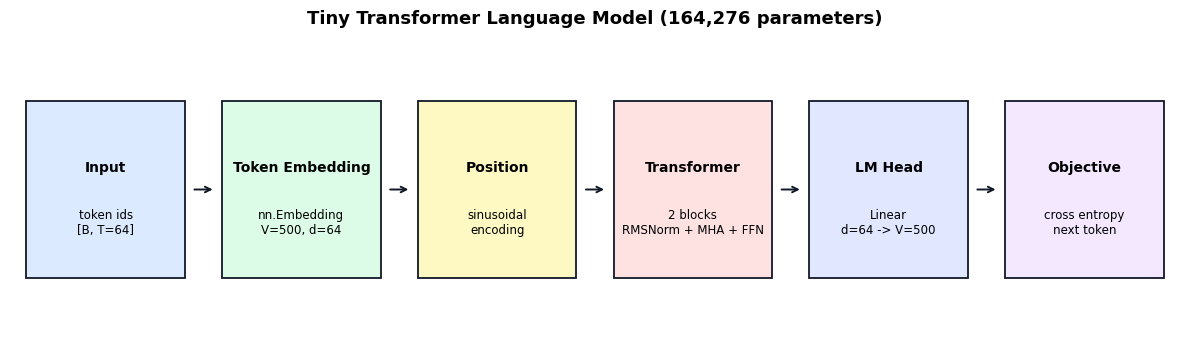

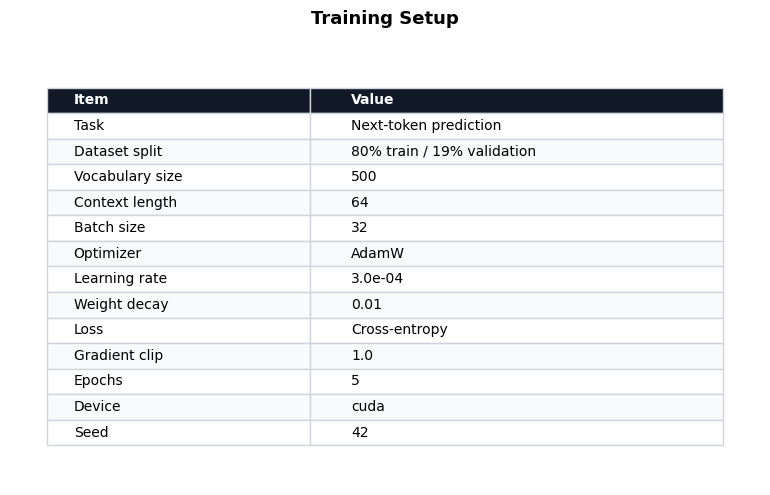

Saved model_architecture.png and training_setup.png


In [24]:
# 10. Visualize model architecture and training setup

def draw_model_architecture(config, filename="model_architecture.png"):
    stages = [
        ("Input", f"token ids\n[B, T={config['block_size']}]") ,
        ("Token Embedding", f"nn.Embedding\nV={vocab_size}, d={config['d_model']}"),
        ("Position", "sinusoidal\nencoding"),
        ("Transformer", f"{config['n_layers']} blocks\nRMSNorm + MHA + FFN"),
        ("LM Head", f"Linear\nd={config['d_model']} -> V={vocab_size}"),
        ("Objective", "cross entropy\nnext token"),
    ]

    fig, ax = plt.subplots(figsize=(12, 3.4))
    ax.axis("off")
    box_w = 1.45
    gap = 0.34
    colors = ["#dbeafe", "#dcfce7", "#fef9c3", "#fee2e2", "#e0e7ff", "#f3e8ff"]

    for i, ((title, detail), color) in enumerate(zip(stages, colors)):
        x = i * (box_w + gap)
        rect = plt.Rectangle((x, 0.18), box_w, 0.64, facecolor=color, edgecolor="#111827", linewidth=1.3)
        ax.add_patch(rect)
        ax.text(x + box_w / 2, 0.58, title, ha="center", va="center", fontsize=10, weight="bold")
        ax.text(x + box_w / 2, 0.38, detail, ha="center", va="center", fontsize=8.5)
        if i < len(stages) - 1:
            ax.annotate(
                "",
                xy=(x + box_w + gap * 0.82, 0.50),
                xytext=(x + box_w + gap * 0.18, 0.50),
                arrowprops=dict(arrowstyle="->", lw=1.4, color="#111827"),
            )

    ax.set_xlim(-0.15, len(stages) * (box_w + gap) - gap + 0.15)
    ax.set_ylim(0.0, 1.0)
    fig.suptitle(f"Tiny Transformer Language Model ({num_params:,} parameters)", fontsize=13, weight="bold")
    fig.tight_layout()
    fig.savefig(filename, dpi=200, bbox_inches="tight")
    plt.show()


def draw_training_setup(config, filename="training_setup.png"):
    rows = [
        ["Task", "Next-token prediction"],
        ["Dataset split", f"{int(config['train_split'] * 100)}% train / {int((1 - config['train_split']) * 100)}% validation"],
        ["Vocabulary size", str(vocab_size)],
        ["Context length", str(config["block_size"])],
        ["Batch size", str(config["batch_size"])],
        ["Optimizer", "AdamW"],
        ["Learning rate", f"{config['learning_rate']:.1e}"],
        ["Weight decay", str(config["weight_decay"])],
        ["Loss", "Cross-entropy"],
        ["Gradient clip", str(config["grad_clip"])],
        ["Epochs", str(config["epochs"])],
        ["Device", DEVICE],
        ["Seed", str(SEED)],
    ]

    fig, ax = plt.subplots(figsize=(7.8, 5.0))
    ax.axis("off")
    table = ax.table(
        cellText=rows,
        colLabels=["Item", "Value"],
        cellLoc="left",
        colLoc="left",
        loc="center",
        colWidths=[0.35, 0.55],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.35)
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor("#d1d5db")
        if row == 0:
            cell.set_facecolor("#111827")
            cell.set_text_props(color="white", weight="bold")
        elif row % 2 == 0:
            cell.set_facecolor("#f9fafb")
    fig.suptitle("Training Setup", fontsize=13, weight="bold")
    fig.tight_layout()
    fig.savefig(filename, dpi=200, bbox_inches="tight")
    plt.show()


draw_model_architecture(CFG)
draw_training_setup(CFG)
print("Saved model_architecture.png and training_setup.png")

## 4. Training

cross-entropy loss

In [25]:
# 11. Training and evaluation loops

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=CFG["learning_rate"],
    weight_decay=CFG["weight_decay"],
)


def run_epoch(model, loader, optimizer=None, max_batches=None):
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    steps = 0

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for step, (x, y) in enumerate(loader):
            if max_batches is not None and step >= max_batches:
                break

            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)

            logits, loss = model(x, y)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])
                optimizer.step()

            total_loss += float(loss.item())
            steps += 1

    return total_loss / max(steps, 1)


history = {"train_loss": [], "val_loss": [], "val_ppl": []}
start_time = time.time()

for epoch in range(1, CFG["epochs"] + 1):
    train_loss = run_epoch(
        model,
        train_loader,
        optimizer=optimizer,
        max_batches=CFG["max_train_batches_per_epoch"],
    )
    val_loss = run_epoch(
        model,
        val_loader,
        optimizer=None,
        max_batches=CFG["max_val_batches"],
    )
    val_ppl = math.exp(min(val_loss, 20))

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_ppl"].append(val_ppl)

    print(
        f"Epoch {epoch:02d} | "
        f"train loss {train_loss:.4f} | "
        f"val loss {val_loss:.4f} | "
        f"val PPL {val_ppl:.2f}"
    )

print(f"Training time: {(time.time() - start_time):.1f} seconds")

Epoch 01 | train loss 4.9081 | val loss 4.2864 | val PPL 72.70
Epoch 02 | train loss 4.1931 | val loss 3.9886 | val PPL 53.98
Epoch 03 | train loss 3.9235 | val loss 3.7818 | val PPL 43.90
Epoch 04 | train loss 3.7314 | val loss 3.6629 | val PPL 38.97
Epoch 05 | train loss 3.6103 | val loss 3.5760 | val PPL 35.73
Training time: 5.8 seconds


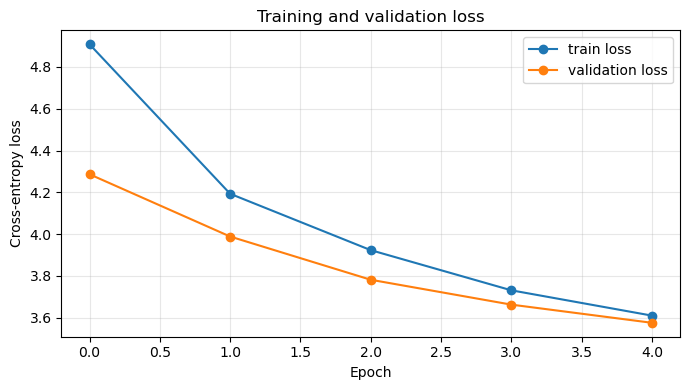

Final validation loss: 3.5760
Final validation perplexity: 35.73


In [26]:
# 12. Plot loss curves and save the figure for your report

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history["train_loss"], marker="o", label="train loss")
ax.plot(history["val_loss"], marker="o", label="validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-entropy loss")
ax.set_title("Training and validation loss")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
fig.savefig("loss_curves.png", dpi=200, bbox_inches="tight")
plt.show()

print(f"Final validation loss: {history['val_loss'][-1]:.4f}")
print(f"Final validation perplexity: {history['val_ppl'][-1]:.2f}")

## 4.1 Learning rate and model size experiments

下面这组实验是给报告的 Experiment Design & Discussion 准备的。

为了节省时间，每个对比实验默认只训练少量 epoch 和 batch。正式报告时可以把 `EXPERIMENT_EPOCHS` 或 `EXPERIMENT_MAX_TRAIN_BATCHES` 调大，但保持所有对比实验使用同样的训练预算。

Group          Experiment             Params   Val loss    Val PPL   Seconds
------------------------------------------------------------------------------
learning_rate  lr=1e-3               164,276     3.6271      37.60       1.9
learning_rate  lr=3e-4               164,276     4.0594      57.94       2.0
learning_rate  lr=1e-4               164,276     4.4713      87.47       1.9
model_size     d=64,L=2              164,276     4.0594      57.94       2.0
model_size     d=128,L=2             524,660     3.7261      41.52       2.0


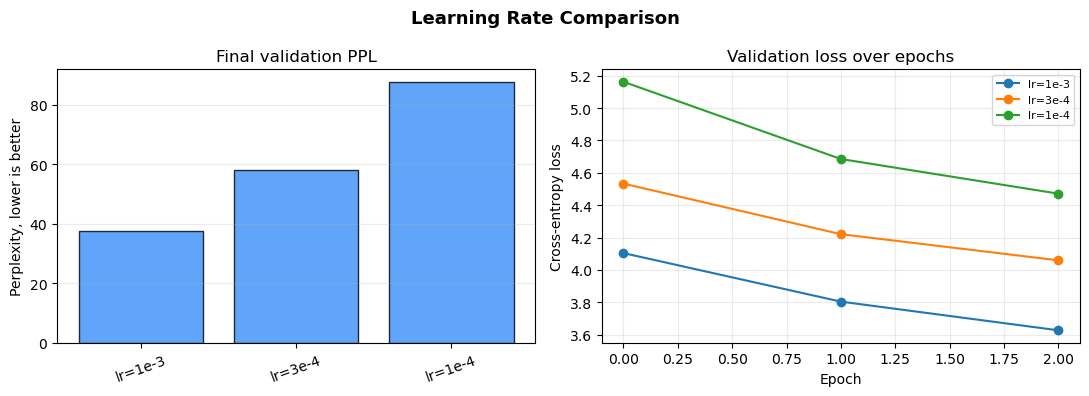

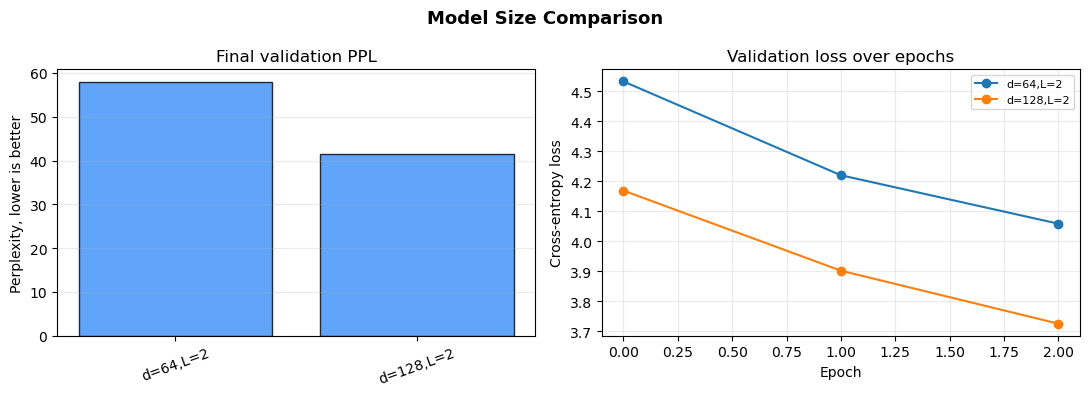

Saved learning_rate_comparison.png, model_size_comparison.png, and experiment_summary.csv


In [27]:
# 13. Compare learning rates and model sizes

EXPERIMENT_EPOCHS = 3
EXPERIMENT_MAX_TRAIN_BATCHES = 80
EXPERIMENT_MAX_VAL_BATCHES = CFG["max_val_batches"]


def reset_random_seed(seed=SEED):
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def make_experiment_config(**overrides):
    config = dict(CFG)
    config.update(overrides)
    assert config["d_model"] % config["n_heads"] == 0
    return config


def train_experiment(label, group, overrides):
    config = make_experiment_config(**overrides)
    reset_random_seed(SEED)

    exp_model = build_model(config)
    exp_optimizer = torch.optim.AdamW(
        exp_model.parameters(),
        lr=config["learning_rate"],
        weight_decay=config["weight_decay"],
    )

    exp_history = {"train_loss": [], "val_loss": [], "val_ppl": []}
    start = time.time()

    for epoch in range(1, EXPERIMENT_EPOCHS + 1):
        train_loss = run_epoch(
            exp_model,
            train_loader,
            optimizer=exp_optimizer,
            max_batches=EXPERIMENT_MAX_TRAIN_BATCHES,
        )
        val_loss = run_epoch(
            exp_model,
            val_loader,
            optimizer=None,
            max_batches=EXPERIMENT_MAX_VAL_BATCHES,
        )
        val_ppl = math.exp(min(val_loss, 20))

        exp_history["train_loss"].append(train_loss)
        exp_history["val_loss"].append(val_loss)
        exp_history["val_ppl"].append(val_ppl)

    result = {
        "group": group,
        "label": label,
        "config": config,
        "history": exp_history,
        "params": count_parameters(exp_model),
        "runtime_sec": time.time() - start,
        "final_val_loss": exp_history["val_loss"][-1],
        "final_val_ppl": exp_history["val_ppl"][-1],
    }

    del exp_model
    if DEVICE == "cuda":
        torch.cuda.empty_cache()
    return result


def print_experiment_table(results):
    print(f"{'Group':<14} {'Experiment':<18} {'Params':>10} {'Val loss':>10} {'Val PPL':>10} {'Seconds':>9}")
    print("-" * 78)
    for r in results:
        print(
            f"{r['group']:<14} {r['label']:<18} {r['params']:>10,} "
            f"{r['final_val_loss']:>10.4f} {r['final_val_ppl']:>10.2f} {r['runtime_sec']:>9.1f}"
        )


def plot_experiment_results(results, title, filename):
    labels = [r["label"] for r in results]
    ppls = [r["final_val_ppl"] for r in results]

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].bar(labels, ppls, color="#60a5fa", edgecolor="#1f2937")
    axes[0].set_title("Final validation PPL")
    axes[0].set_ylabel("Perplexity, lower is better")
    axes[0].tick_params(axis="x", rotation=20)
    axes[0].grid(True, axis="y", alpha=0.25)

    for r in results:
        axes[1].plot(r["history"]["val_loss"], marker="o", label=r["label"])
    axes[1].set_title("Validation loss over epochs")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Cross-entropy loss")
    axes[1].grid(True, alpha=0.25)
    axes[1].legend(fontsize=8)

    fig.suptitle(title, fontsize=13, weight="bold")
    fig.tight_layout()
    fig.savefig(filename, dpi=200, bbox_inches="tight")
    plt.show()


learning_rate_results = [
    train_experiment("lr=1e-3", "learning_rate", {"learning_rate": 1e-3}),
    train_experiment("lr=3e-4", "learning_rate", {"learning_rate": 3e-4}),
    train_experiment("lr=1e-4", "learning_rate", {"learning_rate": 1e-4}),
]

model_size_results = [
    train_experiment("d=64,L=2", "model_size", {"d_model": 64, "n_heads": 4, "n_layers": 2}),
    train_experiment("d=128,L=2", "model_size", {"d_model": 128, "n_heads": 4, "n_layers": 2}),
]

experiment_results = learning_rate_results + model_size_results
print_experiment_table(experiment_results)
plot_experiment_results(learning_rate_results, "Learning Rate Comparison", "learning_rate_comparison.png")
plot_experiment_results(model_size_results, "Model Size Comparison", "model_size_comparison.png")

csv_lines = ["group,label,learning_rate,d_model,n_layers,params,final_val_loss,final_val_ppl,runtime_sec"]
for r in experiment_results:
    c = r["config"]
    csv_lines.append(
        f"{r['group']},{r['label']},{c['learning_rate']},{c['d_model']},{c['n_layers']},"
        f"{r['params']},{r['final_val_loss']:.6f},{r['final_val_ppl']:.6f},{r['runtime_sec']:.2f}"
    )
Path("experiment_summary.csv").write_text("\n".join(csv_lines), encoding="utf-8")
print("Saved learning_rate_comparison.png, model_size_comparison.png, and experiment_summary.csv")

## 5. Attention visualization

这一版会生成多张 attention 图，比单张 heatmap 更适合写报告：

- `attention_layers_heads_sample0.png`: 同一个 sample 下，对比第一层/最后一层、head 0/head 1。
- `attention_heads_structured_sample.png`: 对包含换行、冒号等结构 token 的 sample，对比最后一层多个 heads。
- `attention_heatmap.png`: 单张 close-up heatmap，适合报告中放大解释。

读图方式：横轴是被关注的 token，纵轴是当前 query token。因为用了 causal mask，右上角未来区域应该没有 attention。

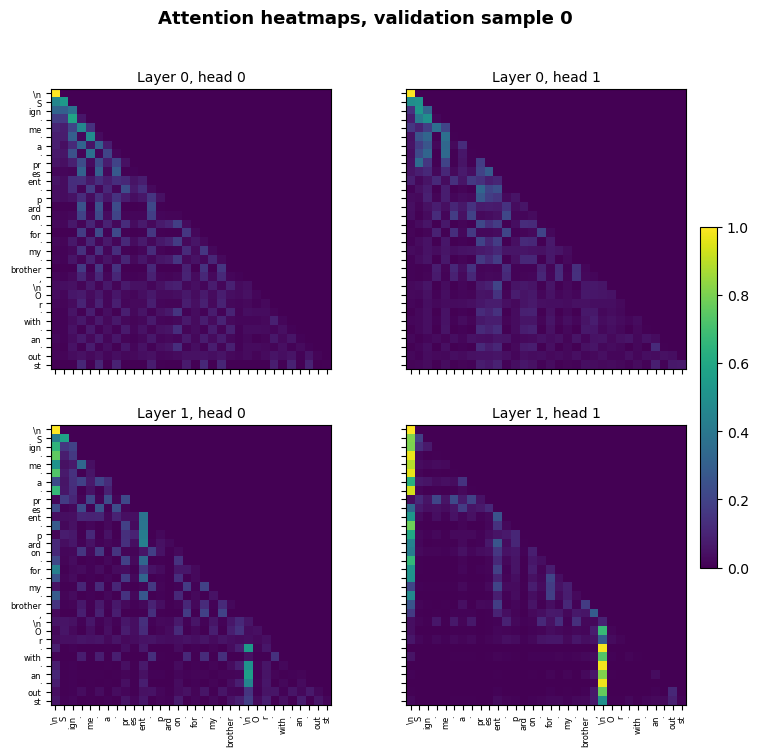

Saved attention_layers_heads_sample0.png
Decoded sequence:
'\nSign me a present pardon for my brother,\nOr with an outst'


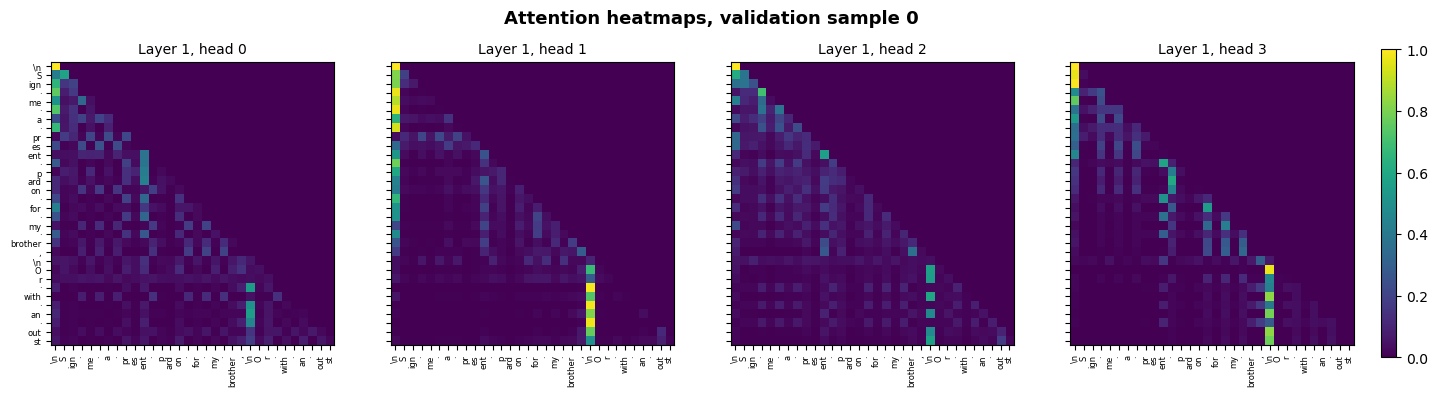

Saved attention_heads_structured_sample.png
Decoded sequence:
'\nSign me a present pardon for my brother,\nOr with an outst'


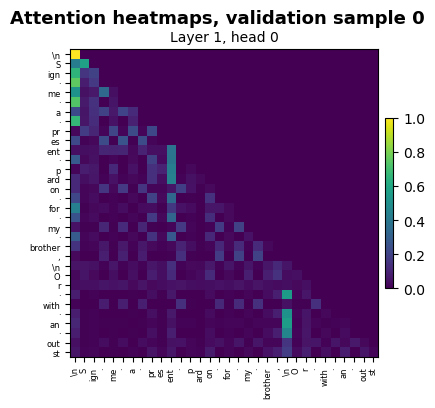

Saved attention_heatmap.png
Decoded sequence:
'\nSign me a present pardon for my brother,\nOr with an outst'
Report prompts:
- Do heads mostly attend to recent tokens, or to special structure tokens such as newline/colon?
- Does the first layer look more local than the final layer?
- Are different heads visibly different, or redundant?


In [28]:
# 14. Enhanced attention visualizations

model.eval()


def find_sequence_index_with_markers(dataset, markers=(":", "\n"), max_scan=500, n_tokens=32):
    for idx in range(min(len(dataset), max_scan)):
        x, _ = dataset[idx]
        decoded = tokenizer.decode(x[:n_tokens].tolist())
        if any(marker in decoded for marker in markers):
            return idx
    return 0


def collect_attention(model, dataset, sample_idx=0, n_tokens=32):
    n_tokens = min(n_tokens, CFG["block_size"])
    x_vis, _ = dataset[sample_idx]
    x_vis = x_vis[:n_tokens].unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        _, _, attentions = model(x_vis, return_attention=True)

    labels = [tokenizer.pretty_token(i) for i in x_vis[0].cpu().tolist()]
    decoded = tokenizer.decode(x_vis[0].cpu().tolist())
    return attentions, labels, decoded


def normalize_layer_index(layer_idx, n_layers):
    return layer_idx if layer_idx >= 0 else n_layers + layer_idx


def plot_attention_grid(
    model,
    dataset,
    sample_idx=0,
    n_tokens=32,
    layer_indices=None,
    head_indices=(0, 1),
    filename="attention_grid.png",
):
    attentions, labels, decoded = collect_attention(model, dataset, sample_idx, n_tokens)
    n_layers = len(attentions)
    n_heads = attentions[0].shape[1]

    if layer_indices is None:
        layer_indices = [0, n_layers - 1] if n_layers > 1 else [0]
    layer_indices = [normalize_layer_index(i, n_layers) for i in layer_indices]
    head_indices = [h for h in head_indices if h < n_heads]

    fig, axes = plt.subplots(
        len(layer_indices),
        len(head_indices),
        figsize=(4.4 * len(head_indices), 4.0 * len(layer_indices)),
        squeeze=False,
    )

    last_image = None
    for row, layer_idx in enumerate(layer_indices):
        for col, head_idx in enumerate(head_indices):
            ax = axes[row][col]
            att = attentions[layer_idx][0, head_idx].cpu()
            last_image = ax.imshow(att, cmap="viridis", vmin=0, vmax=float(att.max()))
            ax.set_title(f"Layer {layer_idx}, head {head_idx}", fontsize=10)

            ax.set_xticks(range(len(labels)))
            ax.set_yticks(range(len(labels)))
            if row == len(layer_indices) - 1:
                ax.set_xticklabels(labels, rotation=90, fontsize=6)
            else:
                ax.set_xticklabels([])
            if col == 0:
                ax.set_yticklabels(labels, fontsize=6)
            else:
                ax.set_yticklabels([])

    if last_image is not None:
        fig.colorbar(last_image, ax=axes.ravel().tolist(), fraction=0.025, pad=0.02)
    fig.suptitle(f"Attention heatmaps, validation sample {sample_idx}", fontsize=13, weight="bold")
    fig.savefig(filename, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"Saved {filename}")
    print("Decoded sequence:")
    print(repr(decoded))
    return decoded


heatmap_tokens = min(32, CFG["block_size"])
structured_idx = find_sequence_index_with_markers(val_ds, n_tokens=heatmap_tokens)
all_heads = list(range(min(CFG["n_heads"], 4)))

sample0_text = plot_attention_grid(
    model,
    val_ds,
    sample_idx=0,
    n_tokens=heatmap_tokens,
    layer_indices=[0, -1],
    head_indices=[0, 1],
    filename="attention_layers_heads_sample0.png",
)

structured_text = plot_attention_grid(
    model,
    val_ds,
    sample_idx=structured_idx,
    n_tokens=heatmap_tokens,
    layer_indices=[-1],
    head_indices=all_heads,
    filename="attention_heads_structured_sample.png",
)

closeup_text = plot_attention_grid(
    model,
    val_ds,
    sample_idx=structured_idx,
    n_tokens=heatmap_tokens,
    layer_indices=[-1],
    head_indices=[0],
    filename="attention_heatmap.png",
)

print("Report prompts:")
print("- Do heads mostly attend to recent tokens, or to special structure tokens such as newline/colon?")
print("- Does the first layer look more local than the final layer?")
print("- Are different heads visibly different, or redundant?")

## 6. Optional: generate sample text
Tiny model, few epoch, low score。

In [29]:
# 15. Optional text generation

@torch.no_grad()
def generate(model, start_text, max_new_tokens=200, temperature=0.9, top_k=40):
    model.eval()
    ids = tokenizer.encode(start_text)
    idx = torch.tensor([ids], dtype=torch.long, device=DEVICE)

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -CFG["block_size"] :]
        logits, _ = model(idx_cond)
        logits = logits[:, -1, :] / max(temperature, 1e-6)

        if top_k is not None:
            k = min(top_k, logits.size(-1))
            values, _ = torch.topk(logits, k)
            logits = logits.masked_fill(logits < values[:, [-1]], float("-inf"))

        probs = F.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)
        idx = torch.cat([idx, next_id], dim=1)

    return tokenizer.decode(idx[0].tolist())

sample = generate(model, "First Citizen:\n", max_new_tokens=200, temperature=0.9, top_k=40)
print(sample)

First Citizen:
Be and the he your soten w to be of der the to bed
F, cessstura the the d that a pa, with this bese so in,
Sir and to frest be of have for to I it the not gal
Ges this the retain of to his I to of pies and and gede, w s
Fiolad of wing and have t, ffin to my g.

NTLIORLORDBI:
ACE:
Sole not
Dend putuon the to


## 7. Report notes template

In [30]:
# 16. Values to copy into your report

print("Model / data summary")
print("--------------------")
print(f"Vocabulary size: {len(tokenizer.id_to_token)}")
print(f"Context length: {CFG['block_size']}")
print(f"Train tokens: {len(train_ids):,}")
print(f"Validation tokens: {len(val_ids):,}")
print(f"d_model: {CFG['d_model']}")
print(f"n_heads: {CFG['n_heads']}")
print(f"n_layers: {CFG['n_layers']}")
print(f"Parameters: {num_params:,}")
print(f"Final validation loss: {history['val_loss'][-1]:.4f}")
print(f"Final validation PPL: {history['val_ppl'][-1]:.2f}")
print()
print("Saved figures / tables:")
print("- model_architecture.png")
print("- training_setup.png")
print("- loss_curves.png")
print("- learning_rate_comparison.png")
print("- model_size_comparison.png")
print("- experiment_summary.csv")
print("- attention_layers_heads_sample0.png")
print("- attention_heads_structured_sample.png")
print("- attention_heatmap.png")

Model / data summary
--------------------
Vocabulary size: 500
Context length: 64
Train tokens: 513,523
Validation tokens: 128,381
d_model: 64
n_heads: 4
n_layers: 2
Parameters: 164,276
Final validation loss: 3.5760
Final validation PPL: 35.73

Saved figures / tables:
- model_architecture.png
- training_setup.png
- loss_curves.png
- learning_rate_comparison.png
- model_size_comparison.png
- experiment_summary.csv
- attention_layers_heads_sample0.png
- attention_heads_structured_sample.png
- attention_heatmap.png
